### <i>Machine Learning-Based Detection and Analysis of Suspicious Activities in Bitcoin Wallet Transactions in the USA </i>
###  <i> Dataset Link -- > https://www.kaggle.com/datasets/larysa21/bitcoin-wallets-data-with-fraudulent-activities </i>
### <i> Import Library Files </i>

In [2]:
import pandas as pd
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")


### <i> Load The Dataset </i>

In [4]:
df = pd.read_csv("btc_wallets_data.csv")
df

,address,hash160,n_tx,n_unredeemed,total_received,total_sent,final_balance
0,bc1qydntupzckl7m09a5mvaqsh5wvhexkt0rrsfjth,2366be0458b7fdb797b4db3a085e8e65f26b2de3,2,0,4200,4200,0
1,1L15W6b9vkxV81xW5HDtmMBycrdiettHEL,d06e25cef9c53166117ad37e4b704ceab914f55f,109450,3,10323281693707,10323281685247,8460
2,bc1q6agcny78pv3jv0qu07ggf9splm5ftnrhc7u5w7,d7518993c70b23263c1c7f90849601fee895cc77,2,0,2499985369,2499985369,0
3,bc1qdf7vsht0vdujptd4dmdzxytunfe04xgakylaau,6a7cc85d6f637920adb56eda23117c9a72fa991d,1,1,60000,0,60000
4,1MusKqjbk497v4Jf1bkgSpKb4aUhjzfoqA,e562279d37914a68e4af5ea40db8ccd1799f8b8e,10,2,15609165,15589185,19980
...,...,...,...,...,...,...,...
8521,bc1q9nej8u8r3m3uvv73jyd9ukrjpce426mw3f0gdd,2cf323f0e38ee3c633d1911a5e58720e33556b6e,6,0,65604768,65604768,0
8522,bc1qj4rgza59au73xqu03pmjr0scydjg4md342325r,9546817685ef3d13038f887721be1823648aedb1,65,0,147881119,147881119,0
8523,1FmsZCgTi9PAkQMzsFDAFMvxbWqJQ1z5Pm,a20e43bfb9969a95dd06cd86e79bebfc6229bce7,0,0,0,0,0
8524,1L3Eaz2arFGZEjRB3Fj9pUzxQaX8WezW2N,d0d690119661442e0a08bda18735767e402675c1,24,7,4882185,2272008,2610177


### <i> Dataset Overview </i>

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8526 entries, 0 to 8525
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   address         8526 non-null   object
 1   hash160         8507 non-null   object
 2   n_tx            8526 non-null   int64 
 3   n_unredeemed    8526 non-null   int64 
 4   total_received  8526 non-null   int64 
 5   total_sent      8526 non-null   int64 
 6   final_balance   8526 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 466.4+ KB


In [7]:
df.describe()

,n_tx,n_unredeemed,total_received,total_sent,final_balance
count,8526.000000,8526.000000,8.526000e+03,8.526000e+03,8.526000e+03
mean,268.184964,9.176636,2.748784e+10,2.739081e+10,9.703451e+07
std,4883.741471,286.916690,6.976181e+11,6.974195e+11,4.932073e+09
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
75%,11.000000,0.000000,1.629697e+07,1.507958e+07,0.000000e+00
max,340546.000000,21596.000000,3.588209e+13,3.588209e+13,4.252747e+11


### <i> Preprocessing </i>

In [9]:
# 1. Handle missing values
print("\nHandling missing values...")

# Check for missing values
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts)


Handling missing values...
Missing values per column:
 address            0
hash160           19
n_tx               0
n_unredeemed       0
total_received     0
total_sent         0
final_balance      0
dtype: int64


In [10]:
# Drop rows with missing `address` or `hash160` (or choose another strategy if required)
df = df.dropna(subset=['address', 'hash160'])

In [11]:
# 2. Check for duplicates
print("\nChecking for duplicates...")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()



Checking for duplicates...
Number of duplicate rows: 20


In [12]:
# 3. Convert data types if necessary
print("\nConverting data types...")

# If `address` and `hash160` are identifiers, ensure they're strings
df['address'] = df['address'].astype(str)
df['hash160'] = df['hash160'].astype(str)


Converting data types...


### <i> Data Visulization And Analysis </i>

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

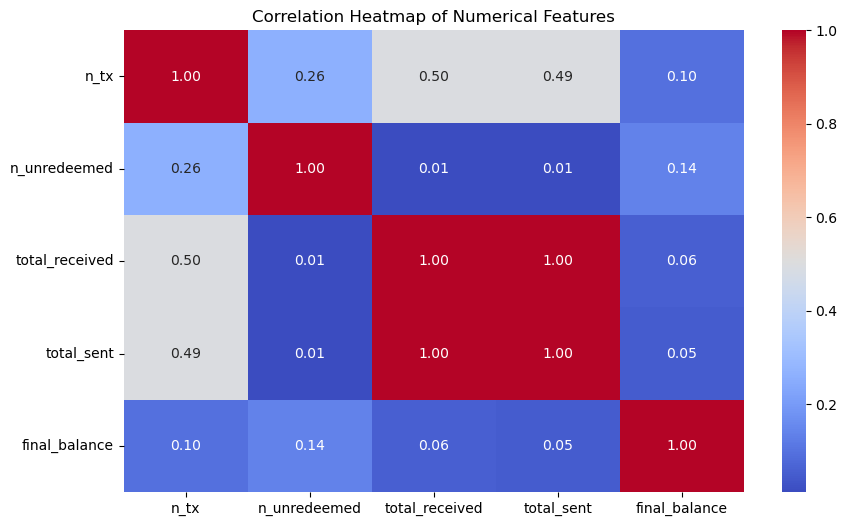

In [15]:
numerical_cols = ['n_tx', 'n_unredeemed', 'total_received', 'total_sent', 'final_balance']


# 3. Correlation Heatmap
plt.figure(figsize=(10, 6))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


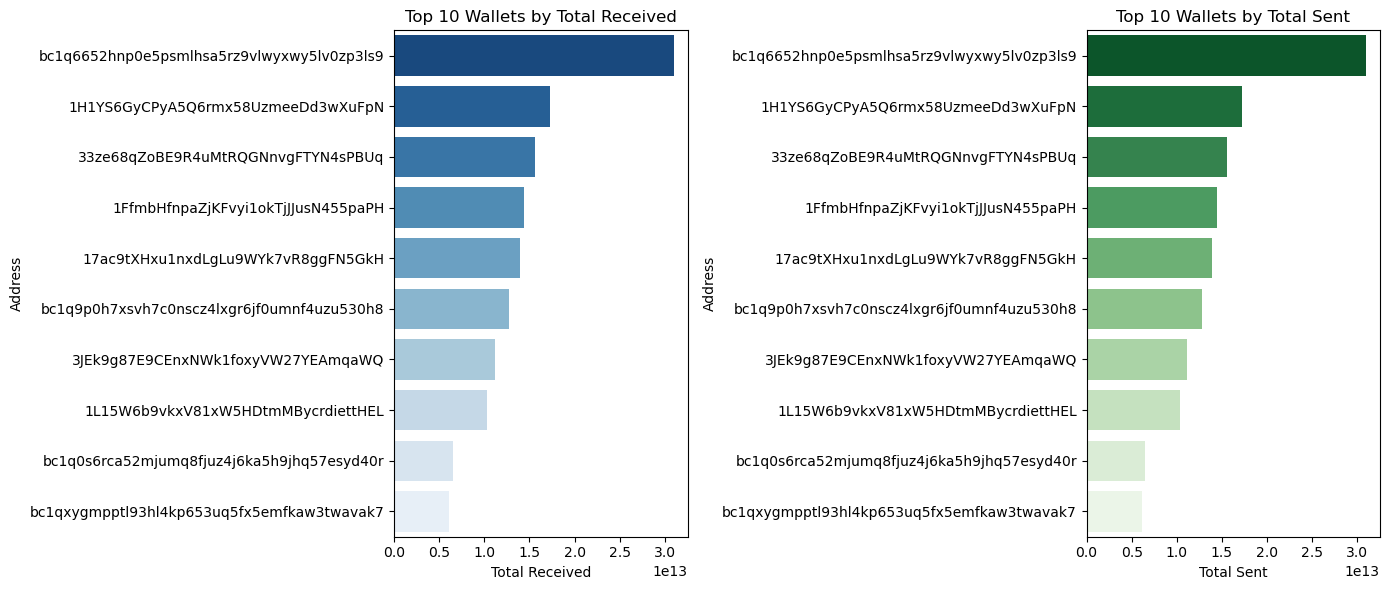

In [16]:
# 4. Top Wallets by Total Received and Total Sent
top_received = df.nlargest(10, 'total_received')
top_sent = df.nlargest(10, 'total_sent')

plt.figure(figsize=(14, 6))

# Top 10 Wallets by Total Received
plt.subplot(1, 2, 1)
sns.barplot(y=top_received['address'], x=top_received['total_received'], palette="Blues_r")
plt.title("Top 10 Wallets by Total Received")
plt.xlabel("Total Received")
plt.ylabel("Address")

# Top 10 Wallets by Total Sent
plt.subplot(1, 2, 2)
sns.barplot(y=top_sent['address'], x=top_sent['total_sent'], palette="Greens_r")
plt.title("Top 10 Wallets by Total Sent")
plt.xlabel("Total Sent")
plt.ylabel("Address")

plt.tight_layout()
plt.show()

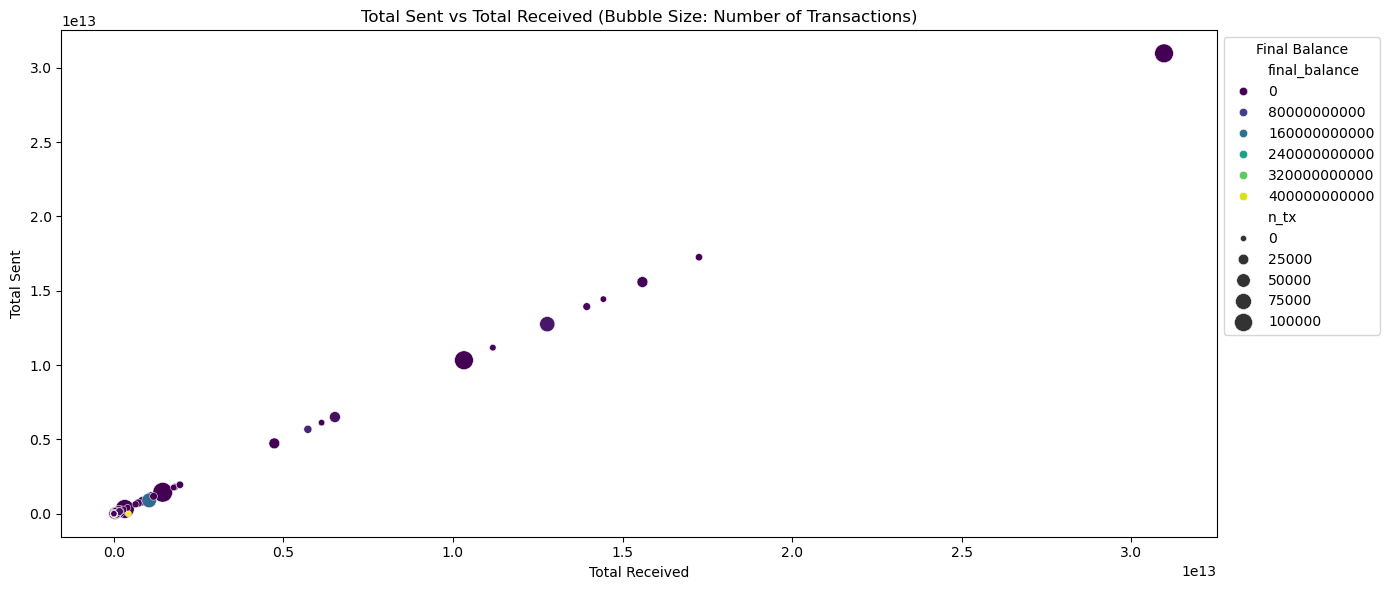

In [17]:
# 6. Transactions Analysis
plt.figure(figsize=(14, 6))
sns.scatterplot(x='total_received', y='total_sent', size='n_tx', hue='final_balance', data=df, palette="viridis", sizes=(20, 200))
plt.title("Total Sent vs Total Received (Bubble Size: Number of Transactions)")
plt.xlabel("Total Received")
plt.ylabel("Total Sent")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Final Balance")
plt.tight_layout()
plt.show()

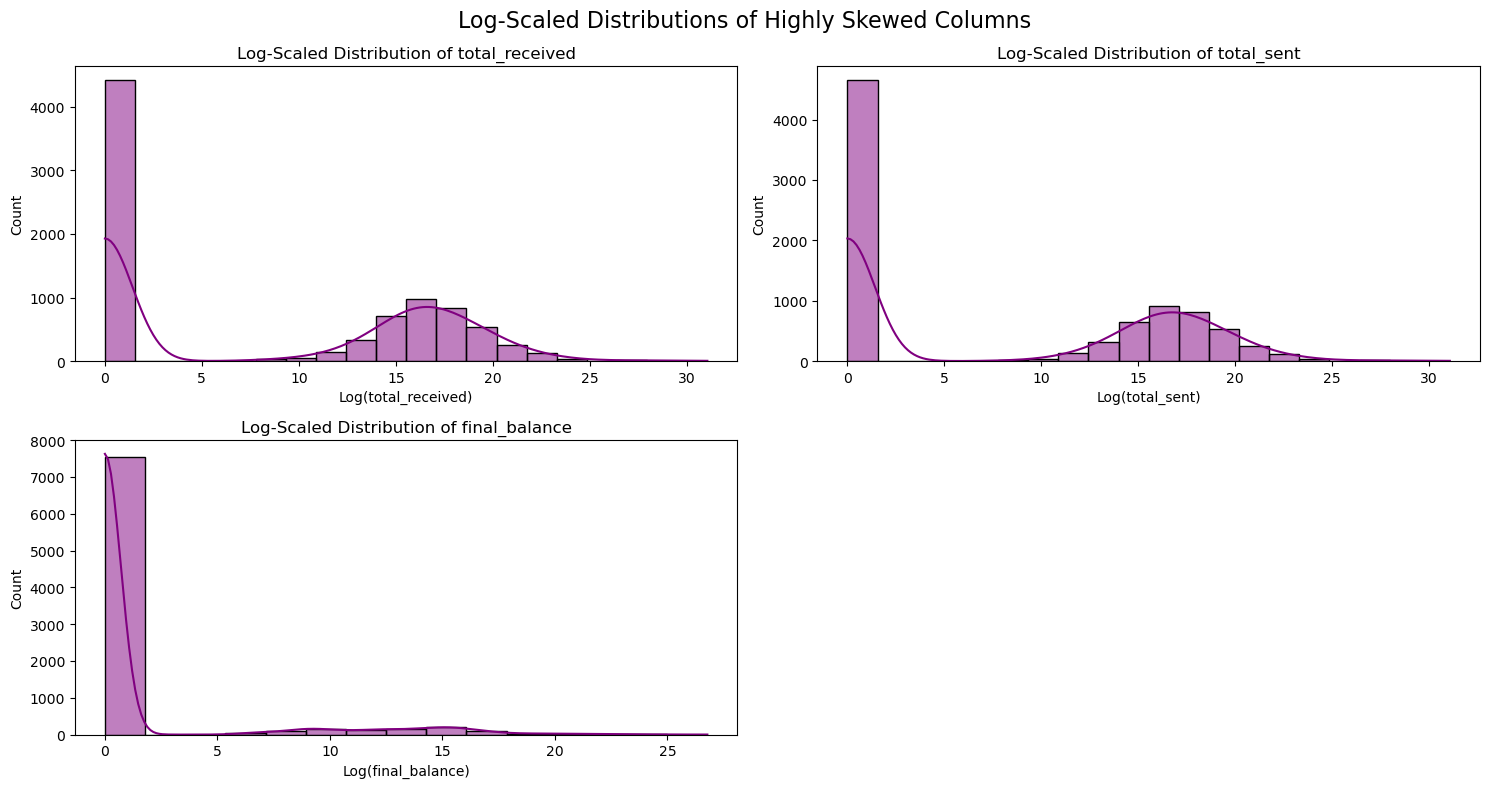

In [18]:
import numpy as np
# 1. Logarithmic Scale Distributions (For highly skewed data)
def plot_log_distributions(data, columns, title):
    """Plots distributions with logarithmic scale for skewed data."""
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(columns, 1):
        plt.subplot(2, (len(columns) + 1) // 2, i)
        sns.histplot(np.log1p(data[col]), kde=True, color='purple')
        plt.title(f'Log-Scaled Distribution of {col}')
        plt.xlabel(f'Log({col})')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

skewed_cols = ['total_received', 'total_sent', 'final_balance']
plot_log_distributions(df, skewed_cols, "Log-Scaled Distributions of Highly Skewed Columns")

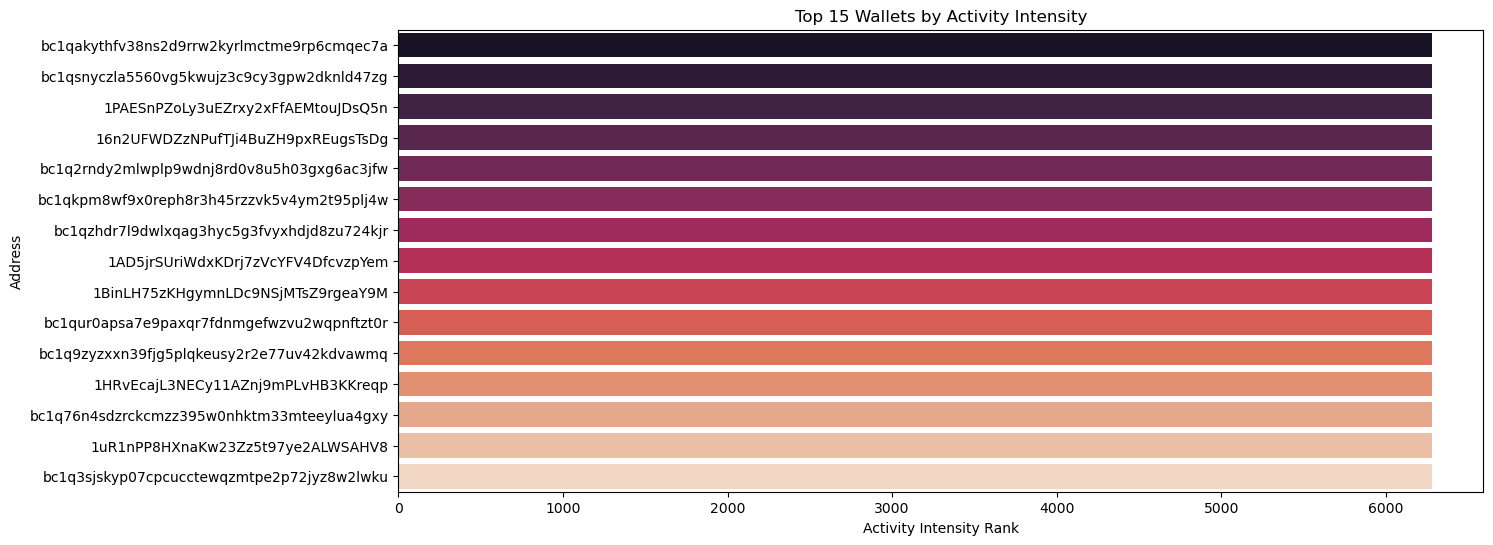

In [19]:
# 5. Activity Intensity by Wallet
activity_intensity = (df['n_tx'] / (df['total_received'] + 1)).rank(ascending=False)
df['activity_intensity_rank'] = activity_intensity

plt.figure(figsize=(14, 6))
top_intense = df.nlargest(15, 'activity_intensity_rank')
sns.barplot(y=top_intense['address'], x=top_intense['activity_intensity_rank'], palette="rocket")
plt.title("Top 15 Wallets by Activity Intensity")
plt.xlabel("Activity Intensity Rank")
plt.ylabel("Address")
plt.show()

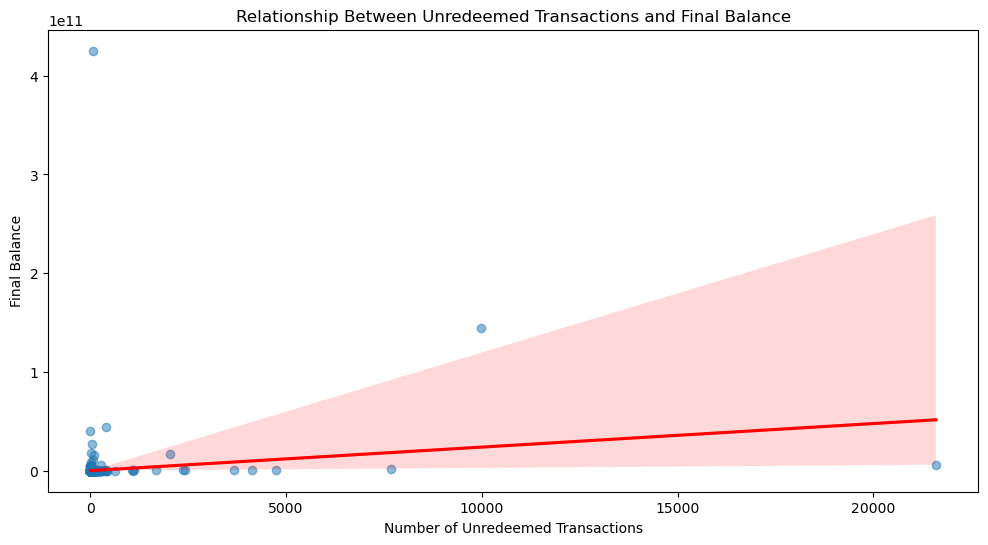

In [20]:
# 6. Relationship Between Unredeemed Transactions and Final Balance
plt.figure(figsize=(12, 6))
sns.regplot(x='n_unredeemed', y='final_balance', data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title("Relationship Between Unredeemed Transactions and Final Balance")
plt.xlabel("Number of Unredeemed Transactions")
plt.ylabel("Final Balance")
plt.show()


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


### <i> Train-Test Split </i>

In [23]:
# Add a target column (dummy example: randomly assign 0 or 1 as placeholder)
# Replace this logic with your actual criteria for labeling suspicious activities
np.random.seed(42)
df['is_suspicious'] = np.random.choice([0, 1], size=len(df), p=[0.8, 0.2])

# Drop unnecessary columns for modeling
X = df.drop(columns=['address', 'hash160', 'is_suspicious'])
y = df['is_suspicious']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


### <i> Modeling </i>
### <i> Logistic Regression And Evaluation  </i>

In [25]:
# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 1. Logistic Regression
print("Logistic Regression:")
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.2f}\n")

Logistic Regression:
Confusion Matrix:
[[2044    0]
 [ 502    1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      2044
           1       1.00      0.00      0.00       503

    accuracy                           0.80      2547
   macro avg       0.90      0.50      0.45      2547
weighted avg       0.84      0.80      0.72      2547

Accuracy: 0.80



### <i> Random Forest And Evaluation </i>

In [27]:
# 2. Random Forest
print("Random Forest Classifier:")
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}\n")

Random Forest Classifier:
Confusion Matrix:
[[1975   69]
 [ 493   10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      2044
           1       0.13      0.02      0.03       503

    accuracy                           0.78      2547
   macro avg       0.46      0.49      0.45      2547
weighted avg       0.67      0.78      0.71      2547

Accuracy: 0.78



### <i> Support Vector Machine And Evaluation </i>

In [29]:
# 3. Support Vector Machine
print("Support Vector Machine (SVM):")
svm_clf = SVC(kernel='rbf', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}\n")


Support Vector Machine (SVM):
Confusion Matrix:
[[2044    0]
 [ 503    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      2044
           1       0.00      0.00      0.00       503

    accuracy                           0.80      2547
   macro avg       0.40      0.50      0.45      2547
weighted avg       0.64      0.80      0.71      2547

Accuracy: 0.80



### <i> Comparision Of All Models </i>

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define a function to evaluate models
def evaluate_model(name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

# Collect results for each model
results = []
results.append(evaluate_model("Logistic Regression", y_test, y_pred_log))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))
results.append(evaluate_model("SVM", y_test, y_pred_svm))

# Create a DataFrame to compare results
comparison_df = pd.DataFrame(results)

# Sort the DataFrame by F1 Score (or any preferred metric)
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

# Print the comparison results
print("Model Comparison Results:")
print(comparison_df)

# Identify the best model
best_model = comparison_df.iloc[0]
print(f"\nThe best model is {best_model['Model']} with an F1 Score of {best_model['F1 Score']:.2f}.")


Model Comparison Results:
                 Model  Accuracy  Precision    Recall  F1 Score
1        Random Forest  0.779348   0.126582  0.019881  0.034364
0  Logistic Regression  0.802905   1.000000  0.001988  0.003968
2                  SVM  0.802513   0.000000  0.000000  0.000000

The best model is Random Forest with an F1 Score of 0.03.


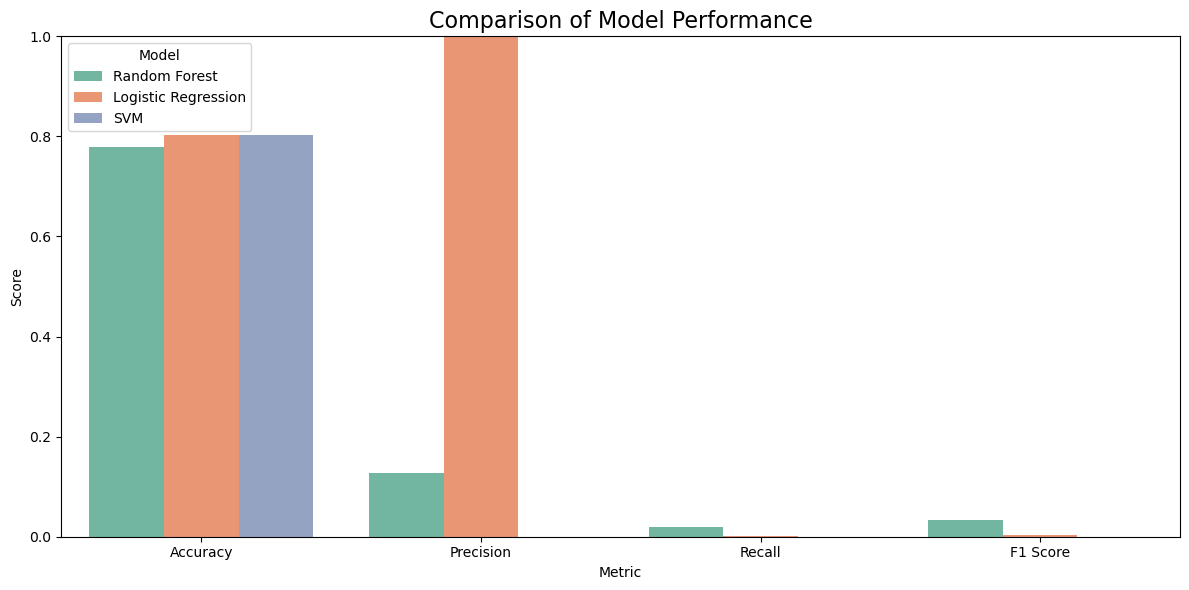

In [32]:
# Visualize model comparison results
def plot_model_comparison(comparison_df):
    """Plots a bar chart for model comparison."""
    metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
    comparison_df_melted = comparison_df.melt(id_vars=["Model"], value_vars=metrics, var_name="Metric", value_name="Score")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=comparison_df_melted, x="Metric", y="Score", hue="Model", palette="Set2")
    plt.title("Comparison of Model Performance", fontsize=16)
    plt.ylabel("Score")
    plt.xlabel("Metric")
    plt.ylim(0, 1)
    plt.legend(title="Model", loc='upper left')
    plt.tight_layout()
    plt.show()

# Call the function to plot
plot_model_comparison(comparison_df)